# 01 · EDA & Preprocessing
PlantVillage (Pepper / Potato / Tomato, 15 class) — khám phá, làm sạch và chia train/val/test dùng chung cho cả 3 model.

In [1]:
import os, sys, json, time
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from src import config, data_prep as dp

sns.set_theme(style="whitegrid", font_scale=0.9)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PALETTE = {"Pepper": "#d95f02", "Potato": "#7570b3", "Tomato": "#1b9e77"}

def savefig(name):  # lưu hình cho báo cáo
    plt.savefig(config.FIGURES_DIR / f"eda_{name}.png", dpi=150, bbox_inches="tight")

def show_img(ax, path, title=None):
    ax.imshow(Image.open(config.RAW_DIR / path)); ax.axis("off")
    if title: ax.set_title(title, fontsize=8)

print("Project root:", ROOT)

Project root: D:\Plant_disease_detection\Plant_disease


## 1. Kiểm kê dữ liệu
Giải mã toàn bộ file: đọc được không, định dạng, kích thước, mode màu.

In [2]:
t = time.time()
raw = dp.scan_images()
ok = raw[raw["readable"]]
print(f"Scanned {len(raw):,} files in {time.time() - t:.1f}s ({raw['size_bytes'].sum() / 1e6:.0f} MB)")
print("Extensions :", raw["ext"].value_counts().to_dict())
print("Sizes (WxH):", ok.groupby([ok["width"].astype(int), ok["height"].astype(int)]).size().to_dict())
print("Color modes:", ok["mode"].value_counts().to_dict())
print("Unreadable :", (~raw["readable"]).sum())

Scanned 20,639 files in 21.7s (342 MB)
Extensions : {'.jpg': 20636, '.png': 1, '': 1, '.jpeg': 1}
Sizes (WxH): {(256, 256): 20638}
Color modes: {'RGB': 20637, 'RGBA': 1}
Unreadable : 1


In [3]:
raw["exclude"] = raw.apply(dp.exclusion_reason, axis=1)
excluded = raw[raw["exclude"].notna()]
print(f"Excluded {len(excluded)} files:")
print(excluded[["path", "size_bytes", "exclude"]].to_string(index=False))

# dữ liệu sạch + thông tin phụ
df = raw[raw["exclude"].isna()].drop(columns=["exclude", "error"]).reset_index(drop=True)
df["crop"] = df["class_dir"].map(dp.crop_of)
df["healthy"] = df["class_dir"].map(dp.is_healthy)
df["name"] = df["class_dir"].map(dp.pretty_name)
print(f"\nClean dataset: {len(df):,} images | {df['name'].nunique()} classes")

Excluded 2 files:
                                                                                                  path  size_bytes             exclude
Pepper__bell___healthy/42f083e2-272d-4f83-ad9a-573ee90e50ec___Screen Shot 2015-05-06 at 4.01.13 PM.png      121652 manual: wrong label
                                                      Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c           0          unreadable

Clean dataset: 20,637 images | 15 classes


Ảnh `.png` là **quả ớt bị bệnh** nhưng nằm trong thư mục *Pepper healthy* → sai nhãn, loại bỏ; file còn lại rỗng (0 byte).

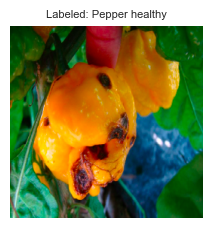

In [4]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
show_img(ax, excluded.loc[excluded["exclude"].str.startswith("manual"), "path"].iloc[0], "Labeled: Pepper healthy")
plt.show()

## 2. Phân bố class

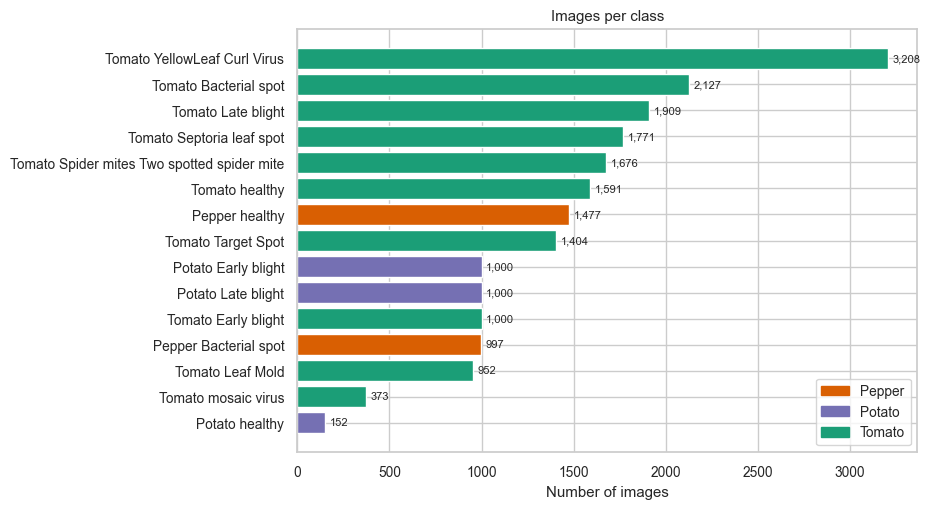

Largest : Tomato YellowLeaf Curl Virus (3,208)
Smallest: Potato healthy (152)
Imbalance ratio (max/min): 21.1x | mean 1376 | median 1404


In [5]:
counts = df["name"].value_counts()
crop_of_name = df.drop_duplicates("name").set_index("name")["crop"]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(counts.index[::-1], counts.values[::-1], color=[PALETTE[crop_of_name[n]] for n in counts.index[::-1]])
for i, v in enumerate(counts.values[::-1]):
    ax.text(v + 25, i, f"{v:,}", va="center", fontsize=8)
ax.set(xlabel="Number of images", title="Images per class")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in PALETTE.values()], PALETTE.keys(), loc="lower right")
savefig("class_distribution"); plt.show()

print(f"Largest : {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x | mean {counts.mean():.0f} | median {counts.median():.0f}")

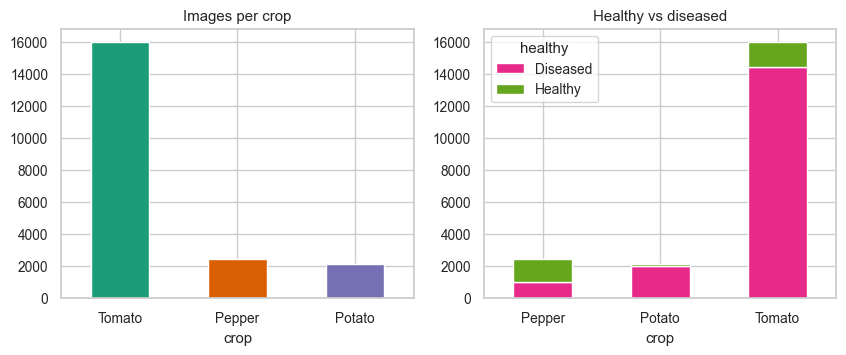

healthy  Diseased  Healthy  Total
crop                             
Pepper        997     1477   2474
Potato       2000      152   2152
Tomato      14420     1591  16011
Total       17417     3220  20637


In [6]:
health = df["healthy"].map({True: "Healthy", False: "Diseased"})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
crop_counts = df["crop"].value_counts()
crop_counts.plot.bar(ax=axes[0], rot=0, color=[PALETTE[c] for c in crop_counts.index], title="Images per crop")
pd.crosstab(df["crop"], health).plot.bar(ax=axes[1], stacked=True, rot=0, color=["#e7298a", "#66a61e"],
                                         title="Healthy vs diseased")
savefig("crop_health"); plt.show()
print(pd.crosstab(df["crop"], health, margins=True, margins_name="Total"))

→ Mất cân bằng mạnh (~21x), Tomato chiếm đa số: dùng **stratified split + `class_weight`**, báo cáo thêm **macro-F1**.

## 3. Ảnh mẫu
5 ảnh ngẫu nhiên mỗi class.

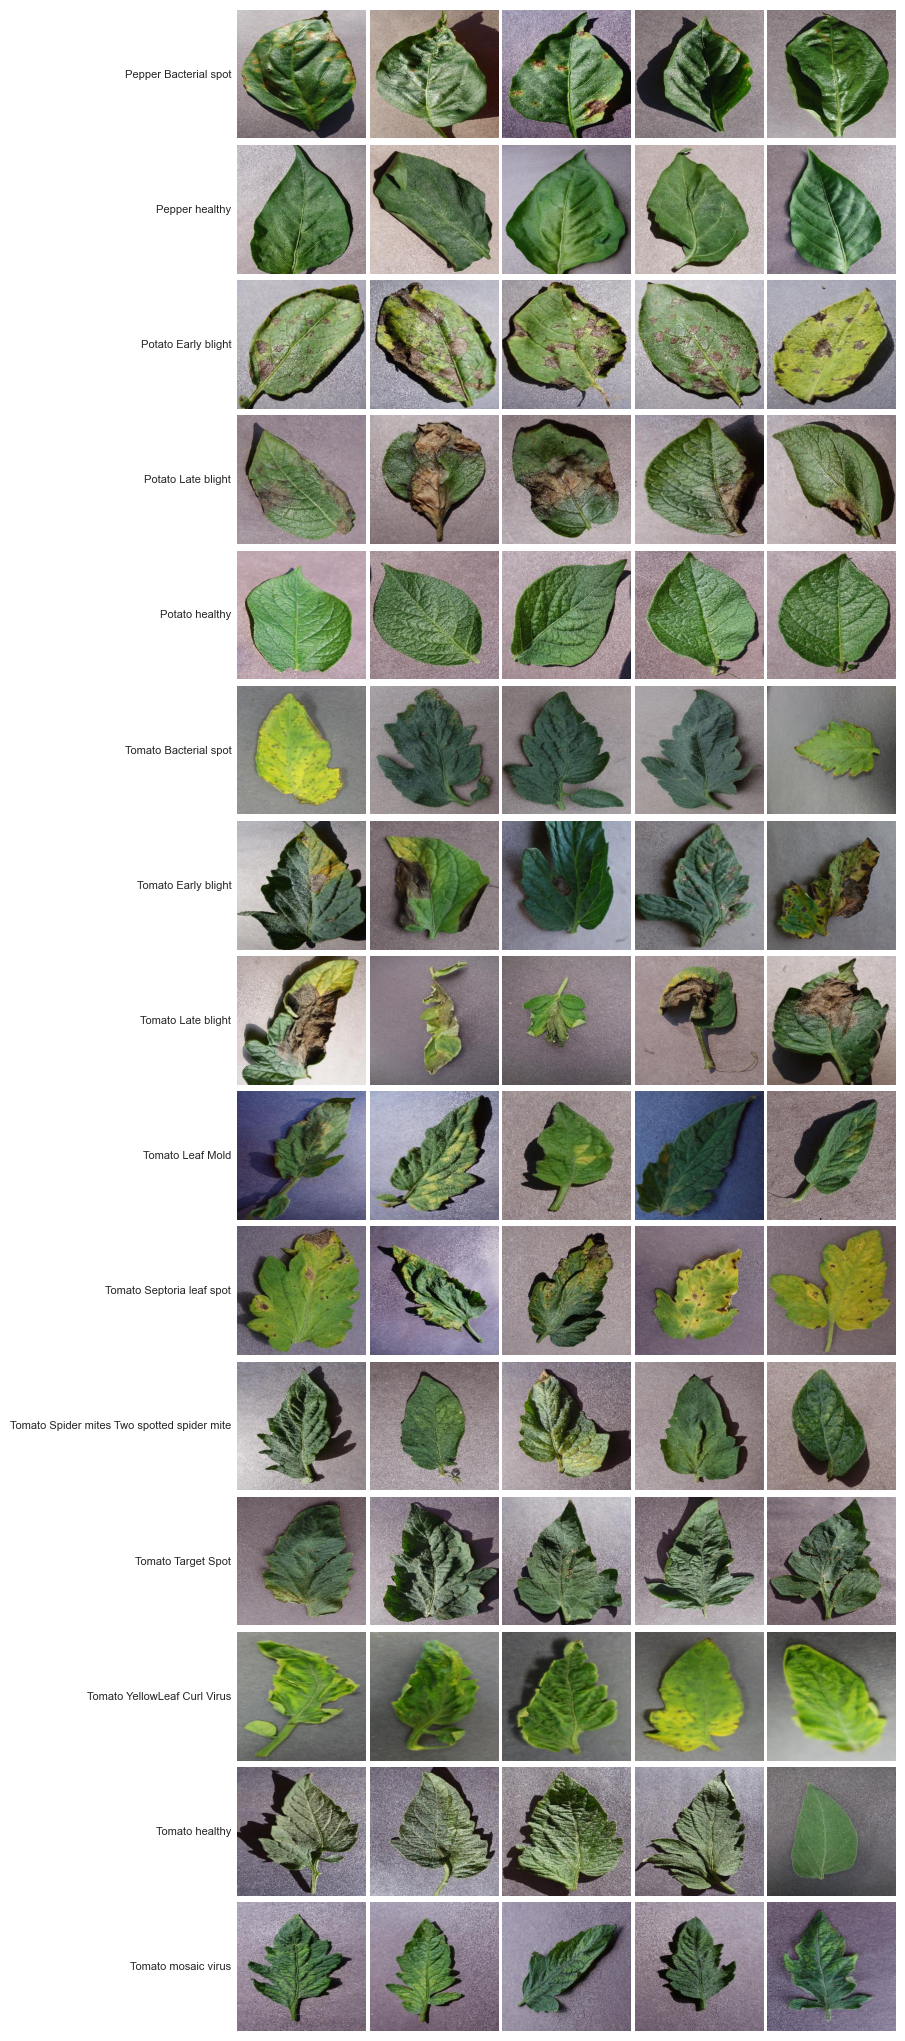

In [7]:
rng = np.random.default_rng(config.SEED)
names = sorted(df["name"].unique())
N = 5
fig, axes = plt.subplots(len(names), N, figsize=(N * 1.7, len(names) * 1.75))
for r, name in enumerate(names):
    paths = df.loc[df["name"] == name, "path"].to_numpy()
    for c, p in enumerate(rng.choice(paths, N, replace=False)):
        show_img(axes[r, c], p)
    axes[r, 0].text(-12, 128, name, ha="right", va="center", fontsize=8)
plt.subplots_adjust(wspace=0.03, hspace=0.05)
savefig("samples"); plt.show()

Ảnh lab: lá đơn, nền trơn, ánh sáng đều → khác xa ảnh đồng ruộng. Màu nền khác nhau giữa các class (VD *Tomato Leaf Mold* nền xanh lam) → nguy cơ model học nền.

## 4. Ảnh trùng & gần trùng
Ảnh trùng (MD5) và ảnh chụp lại cùng lá (tương quan thumbnail 32×32 ≥ 0.95) được gom nhóm → cùng nằm trong một split.

In [8]:
dup_md5 = df[df["md5"].duplicated(keep=False)]
print(f"Exact duplicates: {len(dup_md5)} files in {dup_md5['md5'].nunique()} groups")
print("Exact duplicates across classes:", int((df.groupby("md5")["class_dir"].nunique() > 1).sum()))

df["group"], near = dp.assign_groups(df)
gsize = df["group"].value_counts()
multi = gsize[gsize > 1]
print(f"\nNear-duplicate pairs (corr >= {config.NEAR_DUP_CORR}): {len(near)}")
print(f"Groups: {len(gsize):,} | multi-image groups: {len(multi)} | largest: {gsize.max()} images")
print(f"Images in multi-image groups: {multi.sum()} ({multi.sum() / len(df):.1%})")
print("\nMulti-image groups per class:")
print(df[df["group"].isin(multi.index)].groupby("name")["group"].nunique().sort_values(ascending=False).to_string())

Exact duplicates: 28 files in 14 groups
Exact duplicates across classes: 0



Near-duplicate pairs (corr >= 0.95): 95
Groups: 20,547 | multi-image groups: 79 | largest: 9 images
Images in multi-image groups: 169 (0.8%)

Multi-image groups per class:
name
Tomato healthy                  48
Tomato Late blight              13
Tomato YellowLeaf Curl Virus    10
Pepper healthy                   4
Pepper Bacterial spot            1
Potato Early blight              1
Tomato Bacterial spot            1
Tomato Septoria leaf spot        1


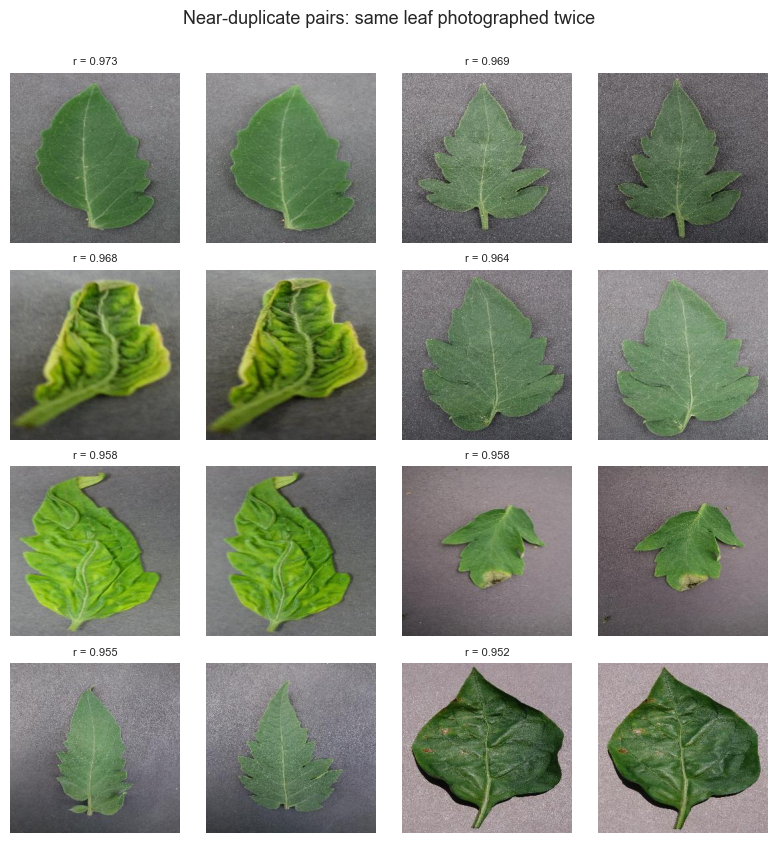

In [9]:
show = near[near["corr"] < 0.999].sample(8, random_state=config.SEED).sort_values("corr", ascending=False)
fig, axes = plt.subplots(4, 4, figsize=(8, 8.4))
for k, (_, row) in enumerate(show.iterrows()):
    for j, p in enumerate([row["path_a"], row["path_b"]]):
        show_img(axes[k // 2, (k % 2) * 2 + j], p, f"r = {row['corr']:.3f}" if j == 0 else "")
plt.suptitle("Near-duplicate pairs: same leaf photographed twice", y=1.0)
plt.tight_layout(); savefig("near_duplicates"); plt.show()

## 5. Chia train / val / test
Stratified theo class, chia theo nhóm ở bước 4 — tỉ lệ 70/15/15, seed 42. Lưu vào `splits/`.

In [10]:
df["split"] = dp.grouped_stratified_split(df)
classes = dp.save_splits(df)

tab = pd.crosstab(df["name"], df["split"])[["train", "val", "test"]]
tab["total"] = tab.sum(axis=1)
print(tab.sort_values("total", ascending=False).to_string())
print("\nOverall:", df["split"].value_counts().to_dict(), "| ratio:",
      df["split"].value_counts(normalize=True).round(3).to_dict())

split                                        train  val  test  total
name                                                                
Tomato YellowLeaf Curl Virus                  2246  481   481   3208
Tomato Bacterial spot                         1489  319   319   2127
Tomato Late blight                            1336  287   286   1909
Tomato Septoria leaf spot                     1240  266   265   1771
Tomato Spider mites Two spotted spider mite   1173  252   251   1676
Tomato healthy                                1115  238   238   1591
Pepper healthy                                1034  222   221   1477
Tomato Target Spot                             983  211   210   1404
Potato Early blight                            700  150   150   1000
Potato Late blight                             700  150   150   1000
Tomato Early blight                            700  150   150   1000
Pepper Bacterial spot                          698  150   149    997
Tomato Leaf Mold                  

Leakage check passed: no duplicate group spans two splits
Saved: ['classes.json', 'pixel_stats.json', 'test.csv', 'train.csv', 'val.csv']


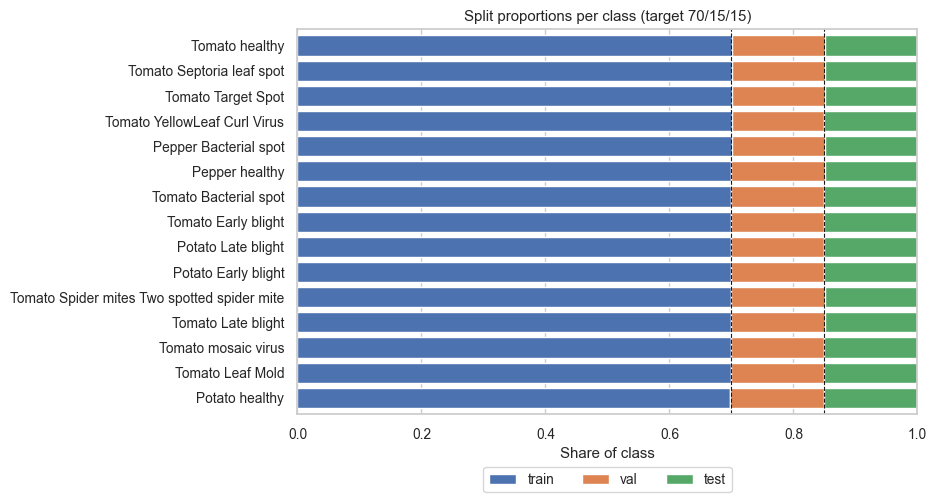

In [11]:
# kiểm tra rò rỉ giữa các split
assert (df.groupby("group")["split"].nunique() == 1).all()
assert (df.groupby("md5")["split"].nunique() == 1).all()
print("Leakage check passed: no duplicate group spans two splits")
print("Saved:", sorted(p.name for p in config.SPLITS_DIR.glob("*.*") if p.suffix in {".csv", ".json"}))

ratio = tab[["train", "val", "test"]].div(tab["total"], axis=0).sort_values("train")
ax = ratio.plot.barh(stacked=True, figsize=(8, 5), color=["#4c72b0", "#dd8452", "#55a868"], width=0.8)
for x in (0.70, 0.85):
    ax.axvline(x, ls="--", c="k", lw=0.8)
ax.set(xlabel="Share of class", ylabel="", title="Split proportions per class (target 70/15/15)", xlim=(0, 1))
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=3)
savefig("split_proportions"); plt.show()

## 6. Thống kê pixel
Mean/std RGB trên tập train (ở 224px) để chuẩn hoá; so sánh màu sắc, độ sáng, nền giữa các class.

In [12]:
t = time.time()
stats = dp.pixel_stats(df.loc[df["split"] == "train", "path"])
(config.SPLITS_DIR / "pixel_stats.json").write_text(json.dumps(stats, indent=2))
print(f"Train RGB mean: {stats['mean']}")
print(f"Train RGB std : {stats['std']}   ({stats['n_images']:,} images, {time.time() - t:.0f}s)")

Train RGB mean: [0.4592, 0.4754, 0.4119]
Train RGB std : [0.1856, 0.1621, 0.2006]   (14,447 images, 59s)


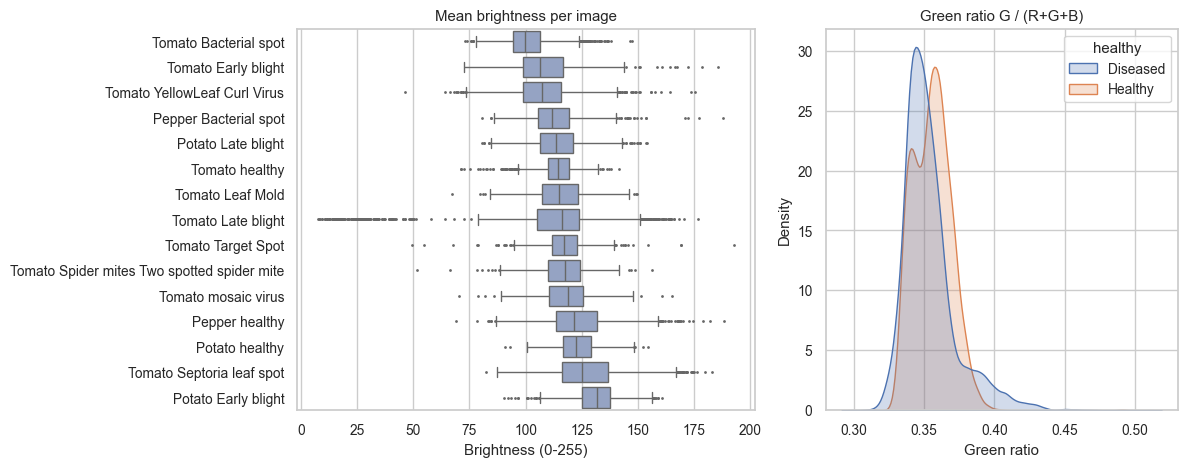

In [13]:
S = config.THUMB_SIZE
th = np.stack(df["thumb"].to_numpy()).reshape(-1, S, S, 3).astype(np.float32)
df[["r", "g", "b"]] = th.mean(axis=(1, 2))
df["brightness"] = df[["r", "g", "b"]].mean(axis=1)
df["green_ratio"] = df["g"] / df[["r", "g", "b"]].sum(axis=1).clip(lower=1)
border = np.concatenate([th[:, 0], th[:, -1], th[:, :, 0], th[:, :, -1]], axis=1).mean(axis=(1, 2))
df["dark_bg"] = border < 40  # viền ảnh gần đen
del th

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
order = df.groupby("name")["brightness"].median().sort_values().index
sns.boxplot(data=df, y="name", x="brightness", order=order, ax=axes[0], fliersize=1, color="#8da0cb")
axes[0].set(title="Mean brightness per image", ylabel="", xlabel="Brightness (0-255)")
sns.kdeplot(data=df, x="green_ratio", hue=df["healthy"].map({True: "Healthy", False: "Diseased"}),
            common_norm=False, fill=True, ax=axes[1])
axes[1].set(title="Green ratio G / (R+G+B)", xlabel="Green ratio")
plt.tight_layout(); savefig("pixel_stats"); plt.show()

Share of images with dark (black) background:
name
Tomato Late blight    7.9%


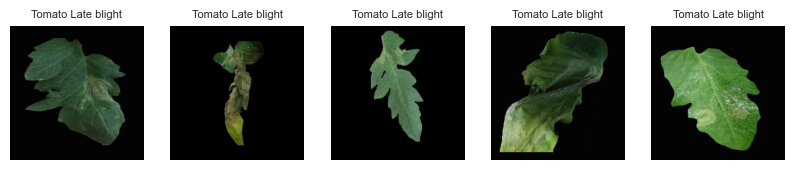

In [14]:
dark = df.groupby("name")["dark_bg"].mean()
print("Share of images with dark (black) background:")
print(dark[dark > 0].sort_values(ascending=False).map("{:.1%}".format).to_string())

fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, p in zip(axes, df.loc[df["dark_bg"], "path"].sample(5, random_state=config.SEED)):
    show_img(ax, p, df.loc[df["path"] == p, "name"].iloc[0])
plt.show()

→ Nền đen chỉ xuất hiện ở một số class → model có thể **học nền thay vì bệnh** (shortcut). Cần kiểm tra lại khi phân tích lỗi.

## 7. Pipeline tiền xử lý dùng chung
`src/data.py`: resize 224×224, augmentation chỉ cho train, hàm `preprocess` tuỳ model.

In [15]:
import tensorflow as tf
from src import data as D

tf.get_logger().setLevel("ERROR")  # ẩn warning của TF 2.10
D.set_seed()
print("TensorFlow", tf.__version__, "| GPUs:", D.enable_gpu_memory_growth())

train_ds, val_ds, test_ds = D.get_datasets(preprocess=D.rescale_01)
x, y = next(iter(train_ds))
print(f"Batch: {tuple(x.shape)} {x.dtype.name}, range [{x.numpy().min():.2f}, {x.numpy().max():.2f}] | labels {tuple(y.shape)}")
print("Batches per epoch (train/val/test):", [int(tf.data.experimental.cardinality(d)) for d in (train_ds, val_ds, test_ds)])

TensorFlow 2.10.1 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Batch: (32, 224, 224, 3) float32, range [0.00, 0.96] | labels (32,)
Batches per epoch (train/val/test): [452, 97, 97]


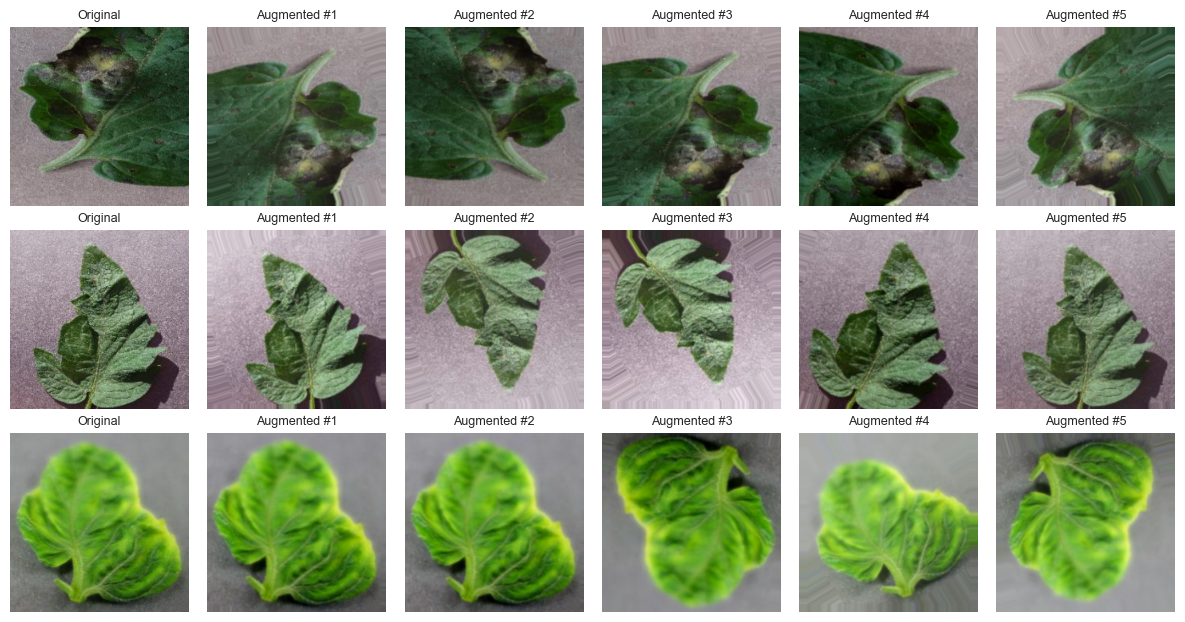

In [16]:
aug = D.build_augmentation()
samples = df[df["split"] == "train"].sample(3, random_state=1)["path"]
fig, axes = plt.subplots(3, 6, figsize=(12, 6.3))
for r, p in enumerate(samples):
    img = tf.image.resize(np.asarray(Image.open(config.RAW_DIR / p)), (config.IMG_SIZE, config.IMG_SIZE))
    axes[r, 0].imshow(img.numpy().astype("uint8")); axes[r, 0].set_title("Original", fontsize=9)
    for c in range(1, 6):
        out = tf.clip_by_value(aug(img, training=True), 0, 255)
        axes[r, c].imshow(out.numpy().astype("uint8")); axes[r, c].set_title(f"Augmented #{c}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); savefig("augmentation"); plt.show()

In [17]:
cw = D.compute_class_weights()
cls = D.class_names()
print("Class weights (balanced):")
print(pd.Series({cls[k]: round(v, 2) for k, v in cw.items()}).sort_values(ascending=False).to_string())

t = time.time()
n = sum(int(xb.shape[0]) for xb, _ in train_ds.take(60))
print(f"\nInput pipeline throughput: {n / (time.time() - t):.0f} images/s (train, with augmentation)")

Class weights (balanced):
Potato healthy                                 9.09
Tomato mosaic virus                            3.69
Tomato Leaf Mold                               1.45
Pepper Bacterial spot                          1.38
Potato Early blight                            1.38
Potato Late blight                             1.38
Tomato Early blight                            1.38
Tomato Target Spot                             0.98
Pepper healthy                                 0.93
Tomato healthy                                 0.86
Tomato Spider mites Two spotted spider mite    0.82
Tomato Septoria leaf spot                      0.78
Tomato Late blight                             0.72
Tomato Bacterial spot                          0.65
Tomato YellowLeaf Curl Virus                   0.43



Input pipeline throughput: 354 images/s (train, with augmentation)


**Cách dùng cho Model 2 / 3:** `get_datasets(preprocess=...)` — Model 1/2: `D.rescale_01` hoặc `D.standardize`; Model 3: `tf.keras.applications.mobilenet_v2.preprocess_input`. Train với `class_weight=D.compute_class_weights()`.

## 8. Tóm tắt

In [18]:
summary = {
    "files_scanned": int(len(raw)),
    "excluded": excluded[["path", "exclude"]].to_dict("records"),
    "clean_images": int(len(df)),
    "num_classes": int(df["name"].nunique()),
    "image_size_raw": "256x256 RGB",
    "class_counts": counts.to_dict(),
    "imbalance_ratio": round(float(counts.iloc[0] / counts.iloc[-1]), 1),
    "exact_duplicate_files": int(len(dup_md5)),
    "near_duplicate_pairs": int(len(near)),
    "images_in_duplicate_groups": int(multi.sum()),
    "split_counts": df["split"].value_counts().to_dict(),
    "train_pixel_stats": stats,
    "dark_background_share": dark[dark > 0].round(3).to_dict(),
    "class_weights": {cls[k]: round(v, 3) for k, v in cw.items()},
}
config.METRICS_DIR.mkdir(parents=True, exist_ok=True)
(config.METRICS_DIR / "eda_summary.json").write_text(json.dumps(summary, indent=2))

# metadata đầy đủ (gitignored) để tra cứu
meta_path = ROOT / "data" / "processed" / "metadata.csv"
meta_path.parent.mkdir(parents=True, exist_ok=True)
df.drop(columns=["thumb"]).to_csv(meta_path, index=False)

print(f"Clean images: {len(df):,} / {len(raw):,} | classes: {df['name'].nunique()}")
print(f"Split: {summary['split_counts']}")
print(f"Imbalance: {summary['imbalance_ratio']}x | duplicate-group images: {multi.sum()}")
print("Saved: outputs/metrics/eda_summary.json, data/processed/metadata.csv, splits/*, outputs/figures/eda_*.png")

Clean images: 20,637 / 20,639 | classes: 15


Split: {'train': 14447, 'val': 3098, 'test': 3092}
Imbalance: 21.1x | duplicate-group images: 169
Saved: outputs/metrics/eda_summary.json, data/processed/metadata.csv, splits/*, outputs/figures/eda_*.png
